# Time Series Mixup

`time_series_mixup(a, b, alpha)` returns $\alpha a + (1-\alpha) b$. Both inputs
must share a shape. `alpha` close to 1 keeps `a`; close to 0 keeps `b`.

This is the 1-D analogue of input mixup: the mixed series lies on the line
segment between two examples and can interpolate their frequencies / trends.

| Parameter | Default | Role |
| --- | --- | --- |
| `alpha` | 0.7 | Weight on the first series `a` |

We mix an ARMA draw with a chirp (synthetic pair) and ETTh1 `OT` with Weather
`OT` (real pair).


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import time_series_mixup

chirp = np.asarray(generate_chirp_signal(L), dtype=float)
weather = load_univariate("weather")[:L].astype(float)
print("pairs", synth.shape, chirp.shape, real.shape, weather.shape)

pairs (512,) (512,) (512,) (512,)


## Default mixup (alpha=0.7)


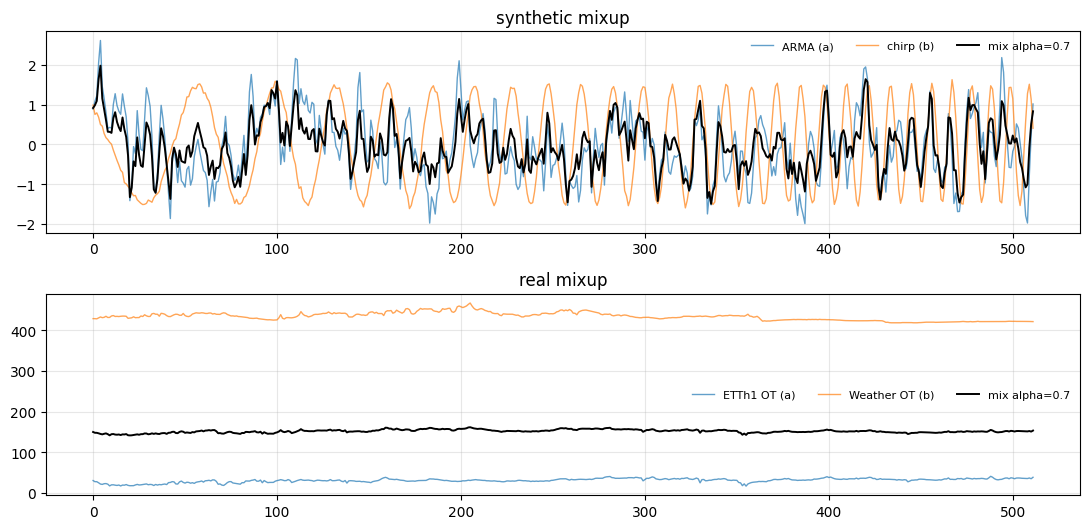

In [2]:
mix_s = time_series_mixup(synth, chirp, alpha=0.7)
mix_r = time_series_mixup(real, weather, alpha=0.7)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.4))
axes[0].plot(synth, color="C0", lw=1.0, alpha=0.7, label="ARMA (a)")
axes[0].plot(chirp, color="C1", lw=1.0, alpha=0.7, label="chirp (b)")
axes[0].plot(mix_s, color="k", lw=1.4, label="mix alpha=0.7")
axes[0].set_title("synthetic mixup")
axes[0].legend(fontsize=8, frameon=False, ncol=3)
axes[0].grid(True, alpha=0.3)

axes[1].plot(real, color="C0", lw=1.0, alpha=0.7, label="ETTh1 OT (a)")
axes[1].plot(weather, color="C1", lw=1.0, alpha=0.7, label="Weather OT (b)")
axes[1].plot(mix_r, color="k", lw=1.4, label="mix alpha=0.7")
axes[1].set_title("real mixup")
axes[1].legend(fontsize=8, frameon=False, ncol=3)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Parameter effect of alpha

As `alpha` decreases from 1 to 0 the mix walks from `a` to `b`. Intermediate
values can look like neither parent if the two series have very different scales
(Weather vs ETTh1).


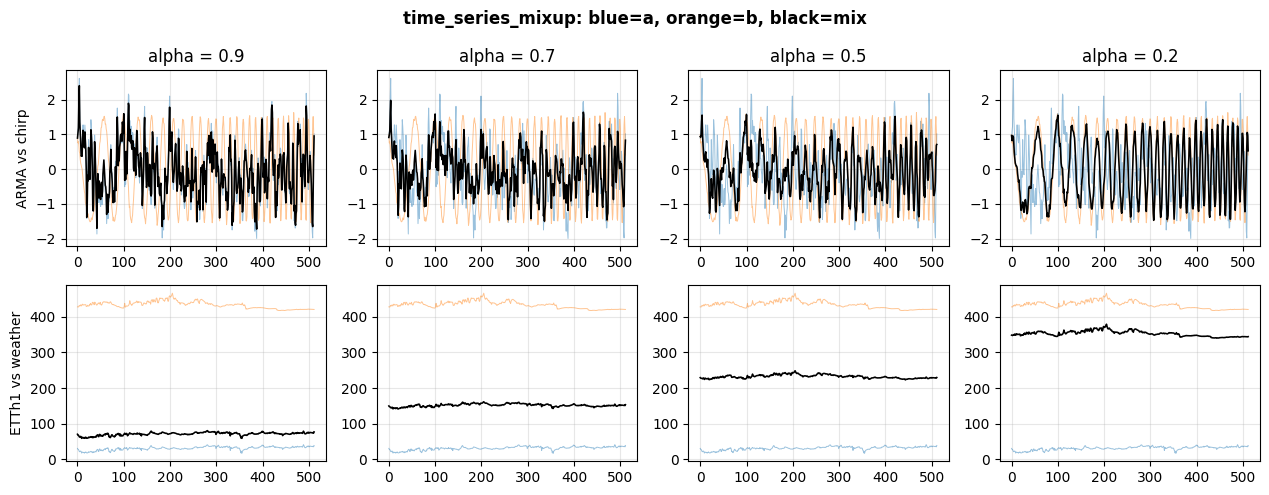

In [3]:
alphas = [0.9, 0.7, 0.5, 0.2]
fig, axes = plt.subplots(2, len(alphas), figsize=(3.2 * len(alphas), 5.0))
pairs = [
    (synth, chirp, "ARMA vs chirp"),
    (real, weather, "ETTh1 vs weather"),
]
for row, (a, b, name) in enumerate(pairs):
    for col, alpha in enumerate(alphas):
        ax = axes[row, col]
        mixed = time_series_mixup(a, b, alpha=alpha)
        ax.plot(a, color="C0", lw=0.7, alpha=0.45)
        ax.plot(b, color="C1", lw=0.7, alpha=0.45)
        ax.plot(mixed, color="k", lw=1.15)
        if row == 0:
            ax.set_title("alpha = %.1f" % alpha)
        if col == 0:
            ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
fig.suptitle("time_series_mixup: blue=a, orange=b, black=mix", fontweight="bold")
fig.tight_layout()
plt.show()